### **P P1. Regresión**

De acuerdo con Wikipedia (2026), un homicidio es la "acción de causar la muerte de otro ser humano".
En México, en el 2024 se registraron un total de 33,550 homicidios en las 32 entidades federativas, según datos del INEGI. De acuerdo con El Economista (2023), México fue el país con la novena tasa más alta de homicidios en América en el 2022, de acuerdo con el "Informe global sobre Homicidios 2023" publicado por la Organización de las Naciones Unidas contra la Droga y el Delito (UNODC).


De acuerdo con Croci, G. y Gomez. J. (2023), en una publicación llamada "Explorando las causas de los homicidios: Una compleja interacción de factores" comentan que las causas de los homicidios dependen del contexto. Violencia política, violencia rural, mercados ilegales, guerra civil, crimen organizado y movimientos guerrilleros podrían afectar la cantidad de homicidios cometidos en el lugar.


Como se mencionó anteriormente, entender las causas de los homicidios es una tarea compleja. Es por eso que en este reporte se pretenden analizar diferentes factores y su relación con la cantidad de homicidios en cada entidad federativa de la República Mexicana, con el fin de encontrar posibles apaciguadores de estos fatales eventos.


---  




Para comenzar, se buscaron las bases de datos de los siguientes factores en la página del INEGI. Posteriormente, en Excel se hizo una pequeña limpieza de los  datos como eliminación de texto (notas), renombramiento de columnas, eliminación de una fila presente en varios de los archivos llamada "Estados Unidos Mexicanos", ya que no era relevante para este proyecto, entre otros detalles.


A continuación se nombran los archivos usando y lo que contienen en ellos, junto con el año al que pertenece la base de datos.


**Bases de datos:**


* "[Homicidios.csv](https://www.inegi.org.mx/app/tabulados/interactivos/?pxq=Mortalidad_Mortalidad_08_733c4167-e790-42a9-8bc7-f290480f41af)" (2024)
    * **Estado** -> Nombre de las 32 entidades federativas.
    * **DefuncionPorHomicidio** -> Cantidad de defunciones por causa de homicidio en cada estado.


* "[Desocupacion.csv](https://www.inegi.org.mx/app/tabulados/default.html?nc=624)" (2024) (*estos datos venían por trimestre, por lo que se obtuvo el promedio de los 4 trimestres para tener un sólo dato*)
    * **Estado** -> Nombre de las 32 entidades federativas.
    * **TasaDesocupacion** -> Porcentaje de personas sin ocupación laboral con respecto a la Población Económicamente Activa (PEA).


* "[DensidadPoblacional.csv](https://en.www.inegi.org.mx/app/tabulados/interactivos/?pxq=Poblacion_Poblacion_07_fb7d5132-39f0-4a6c-b6f6-4cbe440e048d)" (2020)
    * **Estado** -> Nombre de las 32 entidades federativas.
    * **DensidadPoblacional** -> Habitantes por kilómetro cuadrado.


* "[Educación.csv](https://www.inegi.org.mx/app/tabulados/interactivos/?pxq=Educacion_Educacion_13_c457f93a-1497-43b9-8c16-962c4cf3af40)" (ciclo escolar 2024/2025)    
    * **Estado** -> Nombre de las 32 entidades federativas.
    * **EsperanzaEscolaridad** -> Cantidad de años que se espera que una persona entre 5 y 29 años esté inscrita en algún nivel educativo.


* "[Ingreso.csv](https://www.inegi.org.mx/app/tabulados/interactivos/?pxq=Hogares_Hogares_11_861f5732-c3db-4614-be03-741f649d605c)" (2024) (*estos datos venían por trimestre, por lo que se multiplicó por 4 para obtener el valor anual*)
    * **Estado** -> Nombre de las 32 entidades federativas.
    * **IngresoTotal** -> Ingreso anual en pesos mexicanos.


* "[CantidadDeJovenes.csv](https://www.inegi.org.mx/app/tabulados/interactivos/?pxq=Poblacion_Poblacion_01_e60cd8cf-927f-4b94-823e-972457a12d4b)" (2020)
    * **Estado** -> Nombre de las 32 entidades federativas.
    * **15a19anios** -> Cantidad de jóvenes entre 15 y 19 años.


* "[HombresvsMujeres.csv](https://www.inegi.org.mx/app/tabulados/interactivos/?pxq=Poblacion_Poblacion_02_be8efe6d-504a-4d9e-8848-6b578542061b&idrt=123&opc=t)" (2020)
    * **Estado** -> Nombre de las 32 entidades federativas.
    * **HombresvsMujeres** -> Cantidad de hombres por cada 100 mujeres.


  Se eligió un enfoque de regresión lineal múltiple para predecir los homicidios por estado porque todos los factores a analizar son numéricos. Además, un modelo de este estilo permite evaluar de manera directa el efecto de cada variable sobre los homicidios y da la opción de tener una mayor interpretabilidad considerando que cada variable contará con su coeficiente que indicará cuánto y cómo afecta a la cantidad de homicidios.
---


En el bloque de código siguiente se cargan las bases de datos anteriormente mencionadas al espacio de trabajo, importando la librería "pandas" para posteriormente utilizar su función `read_csv()`. Para comprobar que la carga fue exitosa, se utiliza la función `print()` y `head(10)` para imprimir los primeros 10 datos de cada tabla. Luego se utiliza la función `.dtypes` para conocer el tipo de variables en cada base de datos y poder tomar acción en caso de que aparezcan algún tipo de variables que podrían causar un error. Para conocer las dimensiones de cada tabla se utiliza la función `.shape[0]`. Todas las tablas deberían contener 32 filas y 2 columnas. Para no hacer este proceso de manera individual, se crea un lista llamada "**dfs**" con todos los *data frames* que se usan y posteriormente se crea un ciclo `for`. La función `enumerate` se usa para que el ciclo recorra todos los los valores guardados en la lista "**dfs**", comenzando el el "**df1**". Dentro de este ciclo se colocan todas las funciones anteriores para que se ejecuten para cada base de datos sin tener que escribir cada uno manualmente.





In [ ]:
import pandas as pd
df1 = pd.read_csv("Homicidios.csv")
df2 = pd.read_csv("Desocupacion.csv")
df3 = pd.read_csv("DensidadPoblacional.csv")
df4 = pd.read_csv("Educacion.csv")
df5 = pd.read_csv("Ingreso.csv")
df6 = pd.read_csv("CantidadDeJovenes.csv")
df7 = pd.read_csv("HombresVsMujeres.csv")

dfs = [df1, df2, df3, df4, df5, df6, df7]
for i, df in enumerate(dfs, start=1):
    print(f"\n===== DataFrame df{i} =====")
    print("Primeras filas:")
    print(df.head(10))
    print("\nTipos de datos:")
    print(df.dtypes)
    print("\nTamaño (filas, columnas):")
    print(df.shape)


===== DataFrame df1 =====
Primeras filas:
                 Estado  DefuncionPorHomicidio
0        Aguascalientes                    151
1       Baja California                   2460
2   Baja California Sur                     85
3              Campeche                    108
4  Coahuila de Zaragoza                    120
5                Colima                    910
6               Chiapas                    932
7             Chihuahua                   2336
8      Ciudad de México                    978
9               Durango                    110

Tipos de datos:
Estado                   object
DefuncionPorHomicidio     int64
dtype: object

Tamaño (filas, columnas):
(32, 2)

===== DataFrame df2 =====
Primeras filas:
                 Estado  TasaDesocupacion
0        Aguascalientes          3.214861
1       Baja California          2.511450
2   Baja California Sur          2.260872
3              Campeche          1.852175
4  Coahuila de Zaragoza          3.883030
5              

Se puede observar que la variable `Estados` es de tipo `object`. Mientras que las demás variables son de tipo `float64`, si contiene decimales o `int64`, si es un número entero. Ambos tipos de las variables numéricas son compatibles para hacer una regresión lineal múltiple.


Para juntar todos las variables en una sola tabla, se crea una nueva variable `df` y se utiliza la función `merge` que lo que hace es unir dos bases de datos. Esta unión se hace mediante la columna clave `estados`. Se repite este paso con las 5 bases de datos restantes, hasta tener todo en una misma variable. Para verificar que se haya completado el proceso de manera correcta, se imprimen las primeras 10, además de la cantidad de estados que deberían seguir siendo 32.





In [ ]:
df = df1.merge(df2, on="Estado") \
              .merge(df3, on="Estado") \
              .merge(df4, on="Estado") \
              .merge(df5, on="Estado") \
              .merge(df6, on="Estado") \
              .merge(df7, on="Estado")
print(df.head(10))
print("Cantidad de estados:", df.shape[0])

                 Estado  DefuncionPorHomicidio  TasaDesocupacion  \
0        Aguascalientes                    151          3.214861   
1       Baja California                   2460          2.511450   
2   Baja California Sur                     85          2.260872   
3              Campeche                    108          1.852175   
4  Coahuila de Zaragoza                    120          3.883030   
5                Colima                    910          2.197727   
6               Chiapas                    932          2.000461   
7             Chihuahua                   2336          2.379727   
8      Ciudad de México                    978          3.991207   
9               Durango                    110          3.053785   

   DensidadPoblacional  EsperanzaEscolaridad  IngresoTotal  15a19anios  \
0                253.9                  13.7        269457      131967   
1                 52.8                  14.0        303561      315639   
2                 10.8       

---


Antes de hacer cualquier estandarización o cambio, se separa la base de datos en train (80%) y test(20%). Esto se logra importando la librería `train_test_split`. Para asegurar que siempre se partan los datos de la misma manera cada vez que se ejecute el código se utiliza la semilla `random_state=42`. En `y` se guardan los valores de "Defunciones por homicidio". Luego, en `x`, se guardan los datos del DataFrame, dejando fuera la columna "Estados" y "DefuncionesPorHomicidio", usando la función `drop()`.




Un problema que se encontró al revisar los archivos es que cada una de las variables tiene una escala diferente. Hay variables que son tasas, teniendo valores máximos menores a 10, luego están los ingresos, en miles de pesos, y así se pueden encontrar otras variables con esta misma situación.


Para corregir este problema y poder obtener un modelo más claro que no sea dominado por variables con grandes magnitudes, se estandarizan las variables, haciendo que la media de cada variable sea 0 y la desviación estándar sea 1. Esto se logra importando la librería `StandardScaler`, para después crear el objeto `scaler`.
Después se guarda en la variable `x_train_scales`, donde `fit()` calcula la media y desviación estándar de las variables de entrenamiento. Posteriormente se usa `transform()` que aplica la fórmula de estandarización.  
Luego se estandarizan los valores de la sección de prueba, usando la escala obtenida con los datos de entrenamiento. Esto se hace para que no haya fuga de información en el modelo. Es por eso que en la variable `x_test_scaled`se usa sólo la función `transform`, sin la función `fit`.


Al estandarizar, se devuelven los valores en arrays, por no que las columnas no tienen nombre. Para poder tener más calidad manejando las variables, se convierte este resultado a DataFrame, volviendo a incluir los nombres de las columnas y luego imprimirlos para asegurar que se haya realizado correctamente.


Esto se logra con la función `DataFrame()`, la cual crea un DataFrame. Dentro de esta función se incluyen los datos a convertir, se añade de dónde se obtendrán las columnas (`columnas = x_train.columns`), y que se preserven los índices originales para que no se pierda el orden (`index = x_train.index`). Este mismo proceso se hace para los datos de prueba. Posteriormente se imprimen las primeras cinco filas de ambos conjuntos de datos con `head()`.





In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

y = df["DefuncionPorHomicidio"]

x = df.drop(columns=["Estado", "DefuncionPorHomicidio"])

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42)

print('Cantidad de datos para entrenamiento:', x_train.shape)

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)

x_test_scaled = scaler.transform(x_test)


x_train_scaled_df = pd.DataFrame(x_train_scaled, columns=x_train.columns, index=x_train.index)
x_test_scaled_df = pd.DataFrame(x_test_scaled, columns=x_test.columns, index=x_test.index)

print(x_train_scaled_df.head())
print(x_test_scaled_df.head())

Cantidad de datos para entrenamiento: (25, 6)
    TasaDesocupacion  DensidadPoblacional  EsperanzaEscolaridad  IngresoTotal  \
25          0.874551            -0.727286              0.540433      0.941503   
12         -0.714914             0.078295              0.373632     -0.937623   
0           0.928284             0.725451              0.040032      0.680259   
4           1.897436            -0.700372              0.540433      0.564772   
16         -1.123690             1.644192              0.373632     -0.578745   

    15a19anios  HombresvsMujeres  
25   -0.269830          1.180044  
12   -0.211715         -1.217121  
0    -0.698159         -0.226292  
4    -0.222867          0.796498  
16   -0.578098         -0.993385  
    TasaDesocupacion  DensidadPoblacional  EsperanzaEscolaridad  IngresoTotal  \
29         -0.687407            -0.140686             -0.960769     -1.280353   
15         -1.150356            -0.332141             -1.627970     -0.470080   
24         -0.

Una vez ejecutado el bloque de código anterior se puede observar que los valores entre variables ya no cambian dasticamente en temas de escala.

Otro problema potencial en la base de datos es la presencia de multicolinealidad entre variables explicativas. Por ejemplo, la cantidad de jóvenes podría estar correlacionada con la densidad poblacional, así como el ingreso con la educación. La multicolinealidad no afecta la capacidad predictiva global del modelo, pero sí puede generar coeficientes inestables, errores estándar inflados y dificultades para interpretar el efecto individual de cada variable. Para poder evaluar si esto sucede con 2 o más variables, se usa la función `corr()`. Se le agrega la función `abs()` para que arroje sólo los valores absolutos, ya que no se analiza la dirección de esta colinealidad.  
Para ver visualmente la correlación de las variables se imprimirá una *heatmap*, siendo más fuerte el color de la celda para las variables más correlacionadas. Se importan las librerías `seaborn`, para poder visualizar esta información, `matplotlib.pyplot`, para poder crear esta figura, y `numpy`, para poder realizar operaciones matemáticas. Para tener una mejor visualización, se "esconde" la mitad de la tabla de colinealidad, ya que una matriz de correlación es simétrica. Con la función `np.triu()` para sólo mantener el triángulo superior. Con `sns.heatmap()` se crea el mapa. Después con `plt.figura()` se define el tamaño de la tabla y con `plt.show()` se muestra el resultado final.

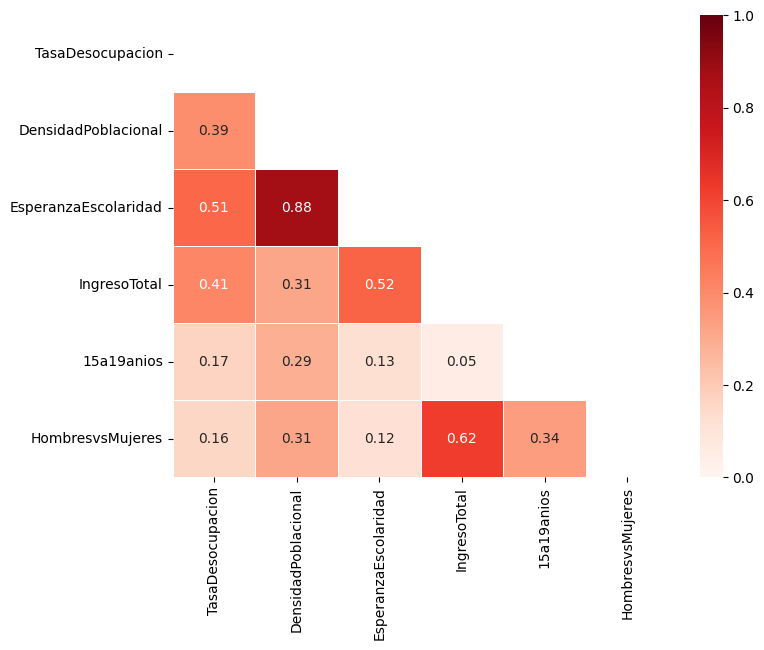

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

corr_matrix = x.corr().abs()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    cmap="Reds",
    fmt=".2f",
    vmin=0,
    vmax=1,
    linewidths=0.5
)

plt.show()

La matriz de correlación en valor absoluto muestra una correlación alta (0.88) entre densidad poblacional y esperanza de escolaridad, lo que sugiere posible multicolinealidad entre estas variables. El resto de las correlaciones se mantienen en niveles moderados o bajos, por lo que no representarían un problema.


Una posible razón por la que la densidad poblacional y la esperanza escolar estén correlacionadas podría ser que entre más población, mayor la infraestructura y oferta educativa, por lo que es más probable que estudien por más tiempo.


Analizando el contexto, estas variables aportan información relevante y diferente. Debido a esto, por el momento, se mantendrán estas variables.  


Otro problema presente es la inconsistencia temporal. Hay datos del 2020 (año de la pandemia en donde hubo muchos valores atípicos) y datos del 2024 (sin considerar los datos del ciclo escolar que también abarcan el 2025). En 4 años pueden ocurrir cambios significativos, por lo que no es recomendable hacer una relación de datos con desalineación temporal. En este caso, no se puede hacer nada al respecto ya que los datos más recientes disponibles en la web son los usados en este reporte. Sólo queda tenerlo presente a la hora de interpretar el modelo, identificando este problema como limitación del estudio.


---


Para poder continuar con la selección de características, se crea un modelo de regresión lineal múltiple, importando la librería `statsmodels.api`, agregado un intercepto con `add_constant()` (usando los valores de `x` estandarizado), creando el modelo con `OLD()` (con los valores de `y` de entrenamiento y el intercepto calculado) y finalmente imprimiendo el resumen del modelo con `model.summary()` para poder analizar su desempeño.





In [ ]:
import statsmodels.api as sm

x_const = sm.add_constant(x_train_scaled_df)
model = sm.OLS(y_train, x_const).fit()
print(model.summary())

                              OLS Regression Results                             
Dep. Variable:     DefuncionPorHomicidio   R-squared:                       0.470
Model:                               OLS   Adj. R-squared:                  0.294
Method:                    Least Squares   F-statistic:                     2.663
Date:                   Sun, 15 Feb 2026   Prob (F-statistic):             0.0499
Time:                           07:23:33   Log-Likelihood:                -200.63
No. Observations:                     25   AIC:                             415.3
Df Residuals:                         18   BIC:                             423.8
Df Model:                              6                                         
Covariance Type:               nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
co

Al ejecutar el código para el modelo de regresión múltiple con todas las variables se encuentra que la única que parece ser estadísticamente significativa, con un 95% de confianza, es la de `15a19anios`, con un p-value de 0.006 (menor a 0.05). Todas las demás variables no muestran tener un efecto en la variable de salida.
La variable con el siguiente menor p-value es `TasaDesocupación`, con un valor de 0.529.


Lo anterior refleja que la cantidad de jóvenes entre 15 y 19 años es un factor asociado con los homicidios, posiblemente porque en este rango de edad suelen ocurrir más conflictos sociales o actos de violencia de todo tipo. Además, la desocupación podría estar relacionada con la cantidad de homicidios debido a que la inestabilidad económica puede generar tensiones y llevar a conflictos, los cuáles podrían involucrar violencia, incluyendo homicidios.


El p-value del estadístico F es de 0.0499, indicando que hay un 4.99% de probabilidad de que todas las variables explicativas tengan cero efecto en la cantidad de homicidios. Al ser menor que 5%, se concluye que el modelo tiene cierta capacidad predictiva significativa, con al menos una variable independiente aportando información relevante.


Sin embargo, se encuentra que el valor de R cuadrada ajustada es de 0.294, indicando que el modelo explica alrededor del 29.4% de la variabilidad en homicidios. Este valor es muy bajo, por lo que este modelo no serviría realmente para predecir efectivamente la cantidad de homicidios con las variables incluidas.


---


A continuación se crea un modelo de regresión lineal múltiple con las variables `15a19anios` y `TasaDesocupacion`, como se comentó anteriormente. Se siguen los mismos pasos implementados en el bloque de código anterior, de igual manera utilizando sólamente los datos de entrenamiento.


Posteriormente se crea un modelo de regresión lineal simple utilizando sólo la variable `15a19anios`, la única variable con un p-value menor a 0.05. Se siguen los mismos pasos para crear el modelo que los modelos pasados.


Para ambos casos se imprimen las estadísticas y resultados de los modelos para ser analizados.





In [ ]:
# Modelo regresión lineal múltiple
print ("Modelo Regresión Lineal Múltiple")
X_multiple = x_train[['15a19anios', 'TasaDesocupacion']]
X_multiple = sm.add_constant(X_multiple)
model_multiple = sm.OLS(y_train, X_multiple).fit()
print(model_multiple.summary())


# Modelo regresión lineal simple¿
print("\nModelo Regresion Lineal Simple")
X_simple = x_train[['15a19anios']]
X_simple = sm.add_constant(X_simple)
model_simple = sm.OLS(y_train, X_simple).fit()
print(model_simple.summary())

Modelo Regresión Lineal Múltiple
                              OLS Regression Results                             
Dep. Variable:     DefuncionPorHomicidio   R-squared:                       0.433
Model:                               OLS   Adj. R-squared:                  0.381
Method:                    Least Squares   F-statistic:                     8.394
Date:                   Sun, 15 Feb 2026   Prob (F-statistic):            0.00195
Time:                           07:23:33   Log-Likelihood:                -201.48
No. Observations:                     25   AIC:                             409.0
Df Residuals:                         22   BIC:                             412.6
Df Model:                              2                                         
Covariance Type:               nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------

 Con el modelo de regresión lineal múltiple con 2 variables y el modelo de regresión lineal simple, se obtuvieron valores de R cuadrada ajustada mayores al modelo que incluía todas las variables; 0.381 y 0.403, respectivamente. De igual manera, el p-value es menor en estos modelos que en el primero.


 **Modelo de Regresión Lineal Múltiple (2 variables)**  
 Con un 95% de certeza se puede decir que la variable `15a19anios` es probabilísticamente significativa para predecir la cantidad de homicidios en un estado. Por el contrario, la variable `TasasDesocupacion` no es probabilísticamente significativa para la variable de salida.  
 Se puede decir que por cada joven entre 15 y 19 años más que haya en la población del estado, la cantidad de homicidios subirá entre 0.001 y 0.004. Por otro lado, para la segunda variable, se puede decir que el intervalo de confianza incluye el cero, lo que indica que el efecto podría ser positivo, negativo o nulo. Por tanto, no existe evidencia estadística suficiente para afirmar que la tasa de desocupación tenga un impacto lineal sobre los homicidios.


 Con un valor de R cuadrada ajustada tan bajo, no es un modelo confiable que podría ser utilizado para predecir la cantidad de homicidios en un estado.


 **Modelo de Regresión Lineal Simple**


 Como `15a19anios` tiene p-value menor a 0.05, esta variable es estadísticamente significativa para explicar un efecto lineal sobre la cantidad de homicidios en un estado. Por cada jóven más entre 15 y 19 años, se espera que los homicidios aumente entre 0.001 y 0.003 unidades.  
 El modelo explica aproximadamente el 40.3% de la variabilidad en la cantidad de homicidios. Este es el mejor modelo hasta ahora.


 ---


 A continuación se pondrán a prueba los últimos 2 modelos realizados, utilizando los valores de prueba. Para comenzar, se guardan los datos utilizados para x en las variables `x_test_multiple` y `x_test_simple`, considerando las variables correspondientes para cada tipo de modelo. Después se agregan 2 constantes para cada modelo. Luego se hacen las predicciones de `y` para cada uno de los modelos. Por último se evalúa el desempeño usando las métricas siguientes:
 * MSE (error cuadrático medio)
 * RMSE (Raíz del MSE)
 * R cuadrada
 Para esto se importa la librería `mean_squared_error` y `r2_score`, que permitirán hacer los cálculos para obtener estos parámetros.


 Se obtiene el valor del MSE utilizando la función `mean_squared_error()`, la cual recibe los parámetros de los valores reales de `y` de la sección de prueba y los valores predichos para `y`. Luego se el RMSE obteniendo la raíz cuadrada del MSE, usando la función `sqrt()` de la librería numpy. Por último, se calcula la R cuadrada usando la función `r2_score()` que toma como parámetros los valores de `y`reales de los datos de prueba y los valores predichos para `y`.  
 Esto se hace para ambos modelos, cambiando los nombres de la variable dependiendo con qué modelo se esté trabajando.


Luego se imprimen los resultados obtenidos para cada modelo, usando `print()` y la variable que se quiere mostrar.




Por último se calcula el promedio de los homicidios de los valores en `test`, para poder hacer un mejor análisis con los resultados que arroje el RMSE.
Esto se hace importando la librería `statistics` y usando la función `mean()`.







In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

# Modelo regresión lineal múltiple
X_test_multiple = x_test[['15a19anios', 'TasaDesocupacion']]
X_test_multiple = sm.add_constant(X_test_multiple)

# Modelo regresión lineal simple
X_test_simple = x_test[['15a19anios']]
X_test_simple = sm.add_constant(X_test_simple)

y_pred_multiple = model_multiple.predict(X_test_multiple)
y_pred_simple = model_simple.predict(X_test_simple)

# Modelo regresión lineal múltiple
mse_multiple = mean_squared_error(y_test, y_pred_multiple)
rmse_multiple = np.sqrt(mse_multiple)
r2_multiple = r2_score(y_test, y_pred_multiple)

# Modelo regresión lineal simple
mse_simple = mean_squared_error(y_test, y_pred_simple)
rmse_simple = np.sqrt(mse_simple)
r2_simple = r2_score(y_test, y_pred_simple)

print("Modelo Múltiple:")
print("MSE:", mse_multiple)
print("RMSE:", rmse_multiple)
print("R2:", r2_multiple)

print("\nModelo Simple:")
print("MSE:", mse_simple)
print("RMSE:", rmse_simple)
print("R2:", r2_simple)

import statistics

promedio_homicidios = statistics.mean(y_test)
print("\nPromedio de homicidios:", promedio_homicidios)


Modelo Múltiple:
MSE: 467733.7963023731
RMSE: 683.9106639776668
R2: -0.5647636866266612

Modelo Simple:
MSE: 474603.26544807246
RMSE: 688.9145559850456
R2: -0.5877449121668479

Promedio de homicidios: 693


Para ambos modelos, se obtuvo un valor de R cuadrada negativo; -0.565 y -0.588, respectivamente.


De acuerdo con StackExchange(2011), un valor de R cuadrada negativa indica que el modelo predice peor que sólo usar una línea recta para modelar el modelo.


El modelo de regresión lineal múltiple tiene un valor de RMSE ligeramente menor que el obtenido con el modelo de regresión lineal simple. En promedio, el modelo múltiple se aleja 684 homicidios del valor real. El modelo simple, en promedio se aleja 689 homicidios del valor real. Considerando que el promedio es de 693 homicidios por año por estado, se puede decir que los modelos se equivocan casi lo mismo que vale el promedio, confirmando que tiene muy baja capacidad predictiva.


De acuerdo con un hilo de Reddit (2023), al tener tan pocos datos (32, los modelos se pueden ver expuestos a "overfitting". El usuario `ewnkenobi` recomienda usar "cross fold validation" cuando se tiene una muestra así de pequeña.


---


Se construyó un modelo de regresión lineal múltiple con fines de inferencia para estudiar la relación entre la cantidad de defunciones por homicidio en los estados y las variables `15a18anios`y `TasaDesocupacion`. El modelo resultó estadísticamente significativo, con una probabilidad del estadístico F de 0.00195 y explicó aproximadamente el 38% de la variabilidad de los homicidios. La única variable significativa en este modelo fue la población de jóvenes de entre 15 y 19 años, con un coeficiente de 0.0023. Con un intérvalo de confianza, se puede decir que el efecto de cada unidad adicional de jóvenes de 15 a 19 años sobre los homicidios está entre 0.001 y 0.004 homicidios. Lo cual se puede traducir en que por cada 1000 jóvenes adicionales en un estado, se espera un aumento promedio de aproximadamente 2.3 homicidios. Por el contrario, la tasa de desocupación no mostró evidencia de ser estadísticamente significativa, teniendo un coeficiente de -104.0, y valores entre -599.58 y 391.57, con un intérvalo de confianza de 95%, ya que su intervalo incluye el cero.


---


Intentar predecir la cantidad de homicidios resultó particularmente difícil, incluso considerando múltiples factores sociales y económicos, debido a que se trata de un fenómeno complejo que depende de una interacción de variables estructurales, culturales y contextuales, como señalan Croci y Gómez (2023) en su estudio Explorando las causas de los homicidios: Una compleja interacción de factores. Incluso comentan que "la hipótesis de que una o un conjunto de
variables pueden explicar las tasas de homicidio no parece cumplirse en todas las regiones". Lo cuál complica el análisis, ya que aunque se encuentre un buen modelo que explique el comportamiento de homicidios de una región, podría no funcionar para otros.

A pesar de que el modelo de regresión lineal múltiple permitió identificar que la población de jóvenes de entre 15 y 19 años está asociada positivamente con la cantidad de homicidios, la capacidad predictiva del modelo fue bastante limitada, casi nula, e incluso incluir otras variables (o cambiarlo a regresión lineal simple), no mostró mejorar en los resultados. Se cree que parte por la que no se obtuvo éxito creando un modelo para predecir la cantidad de homicidios por estado por año, además de la complejidad de este fenómeno, es la pequeña cantidad de muestras para entrenamiento (25 de 32 observaciones) ya que pudo haber incrementado la incertidumbre de los coeficientes, como lo indica Gavilanes & Michael (2019), quien además comenta que se necesitan alrededor de 300 observaciones para obtener coeficientes cercanos a los parámetros de la población.


En el futuro, sería valioso añadir más datos a la base de datos, incluyendo estados de todo el mundo para así poder ampliar el número de muestras y generar un modelo más representativo. Además, sería conveniente hacer este análisis con datos que pertenezcan a la misma línea temporal, para poder tener un mejor entendimiento del fenómeno. Además, sería interesante agregar otras variables no consideradas en este reporte, como el acceso a armas de fuego, narcotráfico presente y seguridad pública, que podrían mostrar relevancia en la incidencia de homicidios. Por último, se podría hacer un uso de otros métodos para analizar el comportamiento de las variables de entrada con las de salida para ver si se tiene un mejor resultado en predicción con alguno de estos métodos.







**Referencias**

* Colaboradores de Wikipedia. (2026, February 6). Homicidio. Wikipedia, La Enciclopedia Libre. https://es.wikipedia.org/wiki/Homicidio
* Pérez, M. (2023, December 11). México, con la novena tasa más alta de homicidios en América. El Economista. https://www.eleconomista.com.mx/politica/Mexico-con-la-novena-tasa-mas-alta-de-homicidios-en-America-20231211-0013.html
* Croci, G., & Gomez, J. (2023). Explorando las causas de los homicidios: Una compleja interacción de factores. In Centro De Estudios Latinoamericanos Sobre Inseguirdad Y Violencia (ISSN 2591-6246). Retrieved February 11, 2026, from https://www.celiv.untref.edu.ar/descargas/explorando-las-causas-de-los-homicidios-una-compleja-interacci%C3%B3n-de-factores.pdf
* Anne. (2011, July 11). When is R squared negative? Cross Validated. https://stats.stackexchange.com/questions/12900/when-is-r-squared-negative
* Machine Learning with Tiny Dataset: Can 30 Samples Predict Rheological Curves? : r/MLQuestions. (n.d.). https://www.reddit.com/r/MLQuestions/comments/1d9d1yv/machine_learning_with_tiny_dataset_can_30_samples/
* Gavilanes, R., & Michael, J. (2019). Low sample size and regression: A Monte Carlo approach. MPRA Paper. https://ideas.repec.org/p/pra/mprapa/97017.html

**Código de Honor**: Doy mi palabra que he realizado esta actividad con integridad académica.  

Se implementó el uso de IA unicamente para dudas de redacción y código.


